# NB10 — Polynomial Regression and Interaction Terms

> **StatQuest: "A curved relationship is still linear regression — you just add x^2 as a new feature."**

---

## The main ideas are:

1. Linear in **parameters** (b0, b1, b2...) != linear in **variables** (x)
2. Adding x^2, x^3 as new columns -> still OLS, just more flexible
3. Risk: too many polynomial terms -> overfitting -> use cross-validation to choose degree
4. Interaction: b3*(x1*x2) -> effect of x1 DEPENDS on value of x2


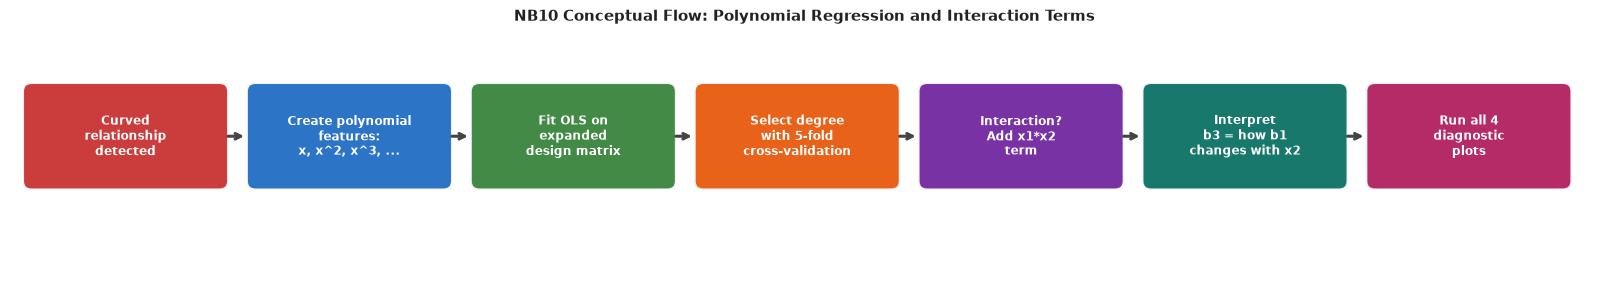

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Curved\nrelationship\ndetected',
        'Create polynomial\nfeatures:\nx, x^2, x^3, ...',
        'Fit OLS on\nexpanded\ndesign matrix',
        'Select degree\nwith 5-fold\ncross-validation',
        'Interaction?\nAdd x1*x2\nterm',
        'Interpret\nb3 = how b1\nchanges with x2',
        'Run all 4\ndiagnostic\nplots',
    ],
    title='NB10 Conceptual Flow: Polynomial Regression and Interaction Terms',
    colors=['#C62828','#1565C0','#2E7D32','#E65100','#6A1B9A','#00695C','#AD1457'],
    figsize=(16, 2.8),
)


## Polynomial regression — the key insight

```
y = b0 + b1*x + b2*x^2 + b3*x^3 + e
```

This is STILL linear regression because:
- b0, b1, b2, b3 appear **linearly** (no b^2 or b*c terms)
- We just create new columns: X1=x, X2=x^2, X3=x^3
- Then OLS solves exactly as before

**Caution:** x^2 and x^3 are HIGHLY correlated with x -> VIF can be large.
Centre x first (subtract mean) to reduce this.


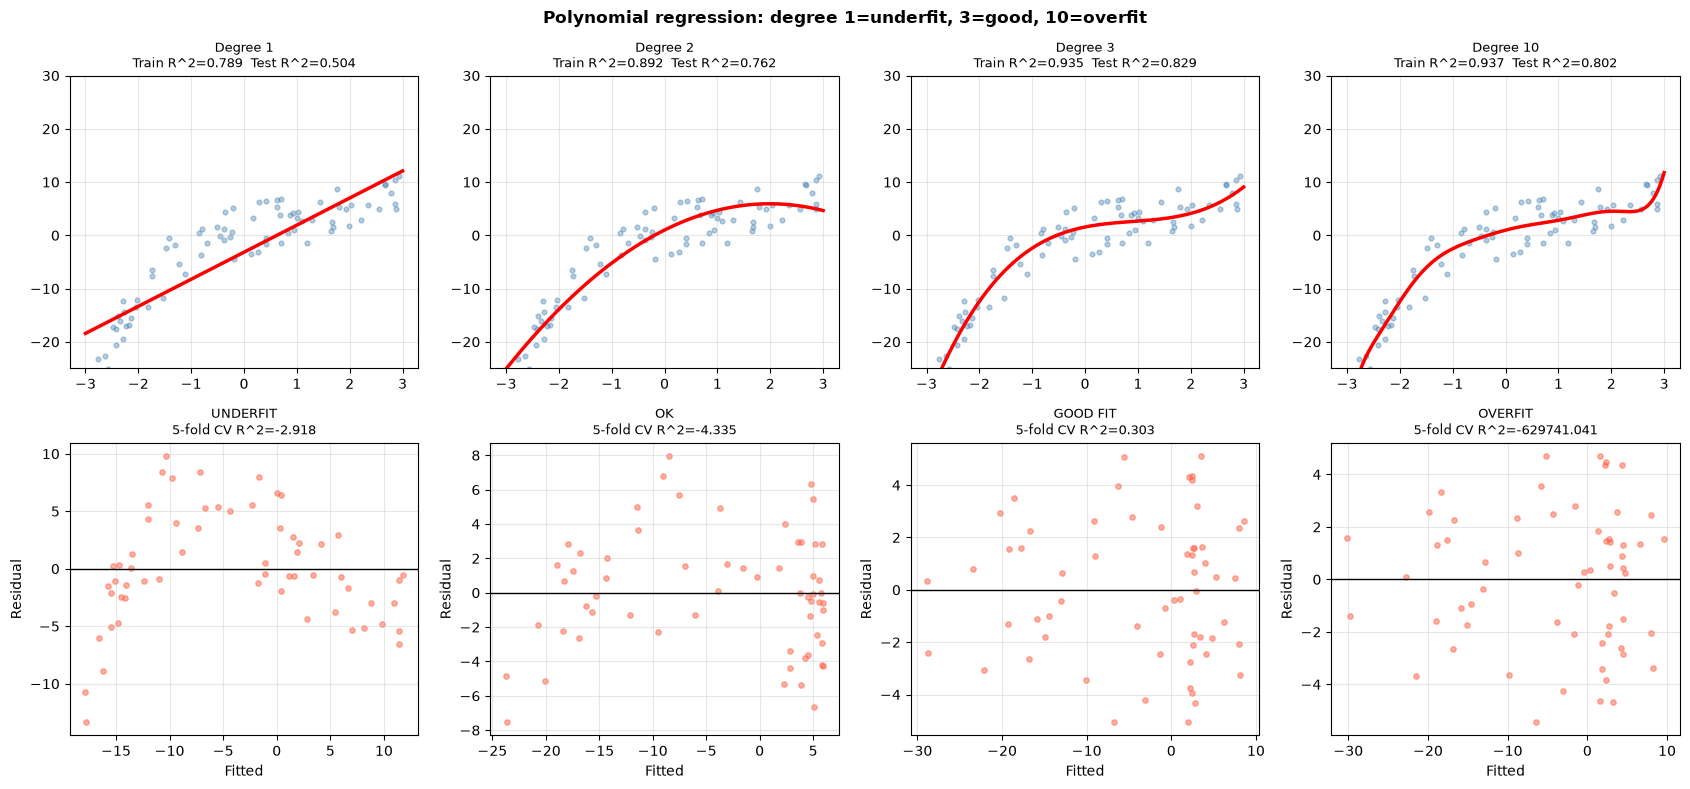

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split

np.random.seed(0)
n = 80
X = np.sort(np.random.uniform(-3, 3, n))
y = 0.5*X**3 - X**2 + 2*X + np.random.normal(0, 3, n)

X_2d    = X.reshape(-1,1)
X_plot  = np.linspace(-3, 3, 300).reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(X_2d, y, test_size=0.25, random_state=1)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
degrees = [1, 2, 3, 10]

for col, deg in enumerate(degrees):
    pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('ols', LinearRegression())])
    pipe.fit(X_tr, y_tr)
    tr_r2 = pipe.score(X_tr, y_tr)
    te_r2 = pipe.score(X_te, y_te)
    cv_r2 = cross_val_score(pipe, X_2d, y, cv=5, scoring='r2').mean()

    ax = axes[0, col]
    ax.scatter(X, y, s=12, alpha=0.4, color='steelblue')
    ax.plot(X_plot, pipe.predict(X_plot), 'r-', linewidth=2.5)
    ax.set_title(f'Degree {deg}\nTrain R^2={tr_r2:.3f}  Test R^2={te_r2:.3f}', fontsize=9)
    ax.set_ylim(-25, 30); ax.grid(alpha=0.3)

    ax = axes[1, col]
    y_hat_tr  = pipe.predict(X_tr)
    resid_tr  = y_tr - y_hat_tr
    ax.scatter(y_hat_tr, resid_tr, s=15, alpha=0.5, color='tomato')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Fitted'); ax.set_ylabel('Residual')
    label = 'UNDERFIT' if deg == 1 else ('GOOD FIT' if deg == 3 else
             'OK' if deg == 2 else 'OVERFIT')
    ax.set_title(f'{label}\n5-fold CV R^2={cv_r2:.3f}', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Polynomial regression: degree 1=underfit, 3=good, 10=overfit',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## Interaction terms — the "it depends" story

```
y = b0 + b1*x1 + b2*x2 + b3*(x1*x2) + e

Slope of x1 = b1 + b3*x2    <- depends on x2!
```

**StatQuest example:**
> "Does the effect of exercise on weight loss depend on diet? If yes, add an interaction term."

If b3 is large and significant: the effect of x1 is DIFFERENT for different values of x2.
If b3 is near zero: x1 and x2 have independent additive effects.


=== WITHOUT interaction ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4657      1.781      5.877      0.000       6.954      13.978
x1             3.7718      0.135     28.002      0.000       3.506       4.037
x2            47.3001      1.521     31.093      0.000      44.300      50.300

=== WITH interaction (exper * edu) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8953      0.881     33.925      0.000      28.157      31.633
x1             1.9588      0.073     26.653      0.000       1.814       2.104
x2            10.0028      1.231      8.125      0.000       7.575      12.431
x3             3.5028      0.102     34.289      0.000       3.301       3.704

Interpretation of interaction coefficient (3.50):
  Slope of e

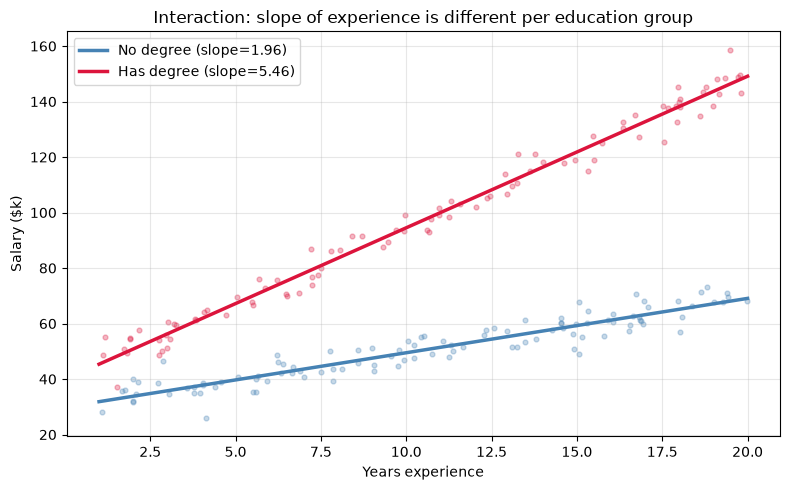

In [3]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(7)
n = 200
edu   = np.random.binomial(1, 0.5, n).astype(float)    # 0 = no degree, 1 = degree
exper = np.random.uniform(1, 20, n)
# True DGP: experience matters MORE for degree holders
salary = 30 + 2.0*exper + 10*edu + 3.5*exper*edu + np.random.normal(0, 4, n)

# Model WITHOUT interaction
X_no = sm.add_constant(np.column_stack([exper, edu]))
res_no = sm.OLS(salary, X_no).fit()

# Model WITH interaction
X_int = sm.add_constant(np.column_stack([exper, edu, exper*edu]))
res_int = sm.OLS(salary, X_int).fit()

print("=== WITHOUT interaction ===")
print(res_no.summary().tables[1])
print("\n=== WITH interaction (exper * edu) ===")
print(res_int.summary().tables[1])

print(f"\nInterpretation of interaction coefficient ({res_int.params[3]:.2f}):")
print(f"  Slope of experience for NO-degree workers: {res_int.params[1]:.2f}")
print(f"  Slope of experience for YES-degree workers: {res_int.params[1]+res_int.params[3]:.2f}")

# Plot
xs = np.linspace(1, 20, 100)
b  = res_int.params
fig, ax = plt.subplots(figsize=(8, 5))
for g, color, label in [(0,'steelblue','No degree'), (1,'crimson','Has degree')]:
    mask = edu == g
    ax.scatter(exper[mask], salary[mask], s=12, alpha=0.3, color=color)
    ys = b[0] + b[1]*xs + b[2]*g + b[3]*xs*g
    ax.plot(xs, ys, color=color, linewidth=2.5, label=f'{label} (slope={b[1]+b[3]*g:.2f})')
ax.set_xlabel('Years experience'); ax.set_ylabel('Salary ($k)')
ax.set_title('Interaction: slope of experience is different per education group')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Key Takeaways

| Technique | When to use | Watch out for |
|-----------|-------------|--------------|
| Polynomial (degree 2-3) | Clearly curved residuals | Overfitting; always use CV |
| Polynomial (degree > 5) | Rarely needed | Almost always overfits |
| Interaction x1*x2 | "Does effect of x1 depend on x2?" | Hard to interpret with 3+ way interactions |

**Cross-validation is mandatory for polynomial regression** — never choose degree by train R^2 alone.

**Next: NB11 — Ridge Regression (L2) to handle overfitting and multicollinearity.**
